In [5]:

# CARE PROJECT — EDA NOTEBOOK


import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

# File paths
BASE      = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
SEPA_PATH = f"{BASE}/001_SEPA/GeoPackage/Data/PVAv2.gpkg"
OSM_BUILD = f"{BASE}/002_OSM/osm_buildings_glasgow.gpkg"
OSM_ROADS = f"{BASE}/002_OSM/osm_roads_glasgow.gpkg"
OSM_WATER = f"{BASE}/002_OSM/osm_water_glasgow.gpkg"
NASA_ELEV = f"{BASE}/003_NASA/nasa_elevation_glasgow.gpkg"
NASA_RAIN = f"{BASE}/003_NASA/nasa_rainfall_monthly_glasgow.gpkg"
MAPS_PATH = f"{BASE}/004_Maps"

# Study area
UNI_X  = 260983
UNI_Y  = 665006
RADIUS = 5000
uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(RADIUS)], crs="EPSG:27700")

print("Imports done!")

Imports done!


In [6]:
# Load SEPA flood zones
pva = gpd.read_file(SEPA_PATH)

print("Shape:", pva.shape)
print("\nFirst 10 rows:")
pva.head(10)

Shape: (235, 8)

First 10 rows:


,OBJECTID_1,PVA_Name,Desig_Date,Chng_C1,PVA_Ref,Shape_Length,Shape_Area,geometry
0,1,Thurso and Halkirk,2018-12-18,Boundary change,02/01/01,84478.694740,1.027316e+08,"MULTIPOLYGON (((308974.999 970125, 308974.999 ..."
1,2,Wick,2018-12-18,Boundary change,02/01/02,100485.288215,8.650975e+07,"MULTIPOLYGON (((334273.843 952200.314, 334261...."
2,3,Lochinver,2018-12-18,Boundary change,02/01/03,57670.830257,4.344988e+07,"MULTIPOLYGON (((209625 923075, 209625 923025, ..."
3,4,Golspie,2011-12-22,No change,02/01/04,36035.606949,2.416975e+07,"MULTIPOLYGON (((283968.105 900005.925, 283962 ..."
4,5,Dornoch,2011-12-22,No change,02/01/05,58566.815141,4.052294e+07,"MULTIPOLYGON (((274774.999 896075, 274775 8960..."
5,6,Aird Point,2018-12-18,New PVA,02/01/06,52469.850623,5.206283e+07,"MULTIPOLYGON (((188555.999 897337.001, 188611 ..."
6,7,Gairloch,2018-12-18,New PVA,02/01/07,96088.344946,7.179356e+07,"MULTIPOLYGON (((180990 875134.999, 181025 8751..."
7,8,Tarbat Ness,2011-12-22,No change,02/01/08,116236.905978,7.762992e+07,"MULTIPOLYGON (((287371 876719, 287339.999 8766..."
8,9,Invergordon,2018-12-18,Boundary change,02/01/09,30046.544683,2.737568e+07,"MULTIPOLYGON (((270875 874925, 270875 874874.9..."
9,10,Alness,2011-12-22,No change,02/01/10,56861.146822,6.002366e+07,"MULTIPOLYGON (((260275 879825.001, 260275 8797..."


In [7]:
print("Column info:")
pva.info()

Column info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OBJECTID_1    235 non-null    int64         
 1   PVA_Name      235 non-null    object        
 2   Desig_Date    235 non-null    datetime64[ms]
 3   Chng_C1       235 non-null    object        
 4   PVA_Ref       235 non-null    object        
 5   Shape_Length  235 non-null    float64       
 6   Shape_Area    235 non-null    float64       
 7   geometry      235 non-null    geometry      
dtypes: datetime64[ms](1), float64(2), geometry(1), int64(1), object(3)
memory usage: 14.8+ KB


In [8]:
print("Descriptive statistics:")
pva.describe()

Descriptive statistics:


,OBJECTID_1,Desig_Date,Shape_Length,Shape_Area
count,235.000000,235,235.000000,2.350000e+02
mean,118.000000,2016-01-18 08:16:20.425000,65792.833829,5.942696e+07
min,1.000000,2011-12-22 00:00:00,10118.278014,1.999455e+06
25%,59.500000,2011-12-22 00:00:00,37020.943642,2.492000e+07
50%,118.000000,2018-12-18 00:00:00,53700.018100,4.655250e+07
75%,176.500000,2018-12-18 00:00:00,78700.018900,7.509303e+07
max,235.000000,2018-12-18 00:00:00,525401.409285,3.076820e+08
std,67.982841,NaN,52284.575099,5.173551e+07


In [9]:
print("Null values per column:")
print(pva.isnull().sum())
print(f"\nTotal nulls: {pva.isnull().sum().sum()}")
print(f"CRS: {pva.crs}")

Null values per column:
OBJECTID_1      0
PVA_Name        0
Desig_Date      0
Chng_C1         0
PVA_Ref         0
Shape_Length    0
Shape_Area      0
geometry        0
dtype: int64

Total nulls: 0
CRS: EPSG:27700


In [10]:
# Filter to 5km study area
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(RADIUS))].copy()

print(f"All Scotland zones: {len(pva)}")
print(f"Glasgow study area: {len(pva_glasgow)}")
print("\nGlasgow flood zones:")
print(pva_glasgow[['PVA_Name', 'PVA_Ref', 'Shape_Area']].to_string(index=False))

All Scotland zones: 235
Glasgow study area: 7

Glasgow flood zones:
                     PVA_Name  PVA_Ref   Shape_Area
                 River Kelvin 02/11/04 1.859940e+08
          Glasgow City centre 02/11/05 4.271800e+06
           Glasgow City north 02/11/06 2.465605e+07
       Luggie Water catchment 02/11/07 1.126656e+08
East of Glasgow to Strathaven 02/11/10 1.502328e+08
                   Rutherglen 02/11/16 1.244148e+07
   White Cart Water catchment 02/11/17 2.091868e+08


In [11]:
buildings = gpd.read_file(OSM_BUILD)

print("Shape:", buildings.shape)
print("\nFirst 5 rows:")
buildings.head(10)

Shape: (55638, 7)

First 5 rows:


,element,id,building,building:levels,height,name,geometry
0,node,1495513134,yes,None,None,The Hengler's Circus,POINT (258251.041 665933.24)
1,node,1705790482,yes,None,None,None,POINT (261171.756 663284.757)
2,node,1936303000,hotel,None,None,Fraser Suites,POINT (259568.006 664953.44)
3,node,2180409219,construction,None,None,Next,POINT (259150.854 665012.542)
4,node,2371954470,dormitory,None,None,Queen Margaret Halls,POINT (256448.68 668027.705)
5,node,2452854341,garage,None,None,None,POINT (261017.459 664194.037)
6,node,3218826826,university,None,None,Department of Theology & Religious Studies,POINT (256796.717 666714.266)
7,node,3813079919,commercial,None,None,Esso - Kelvinside,POINT (257520.079 667893.428)
8,node,5001302993,retail,None,None,Holland & Barrett,POINT (258752.96 665252.981)
9,node,5159005096,warehouse,None,None,Mammoet Ferry Transport (UK) BV,POINT (264035.06 661463.622)


In [12]:
print("Info:")
buildings.info()

print("\nNull values:")
print(buildings.isnull().sum())
print(f"\nTotal nulls: {buildings.isnull().sum().sum()}")
print(f"CRS: {buildings.crs}")

Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 55638 entries, 0 to 55637
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   element          55638 non-null  object  
 1   id               55638 non-null  int64   
 2   building         55638 non-null  object  
 3   building:levels  5588 non-null   object  
 4   height           259 non-null    object  
 5   name             1848 non-null   object  
 6   geometry         55638 non-null  geometry
dtypes: geometry(1), int64(1), object(5)
memory usage: 3.0+ MB

Null values:
element                0
id                     0
building               0
building:levels    50050
height             55379
name               53790
geometry               0
dtype: int64

Total nulls: 159219
CRS: EPSG:27700


In [13]:
print("Building types (value counts):")
print(buildings['building'].value_counts().head(15))

Building types (value counts):
building
yes                   28798
house                 10344
residential            6269
apartments             5427
semidetached_house     1141
terrace                 691
industrial              582
retail                  326
garage                  277
commercial              275
detached                168
roof                    166
office                  152
school                  142
university              141
Name: count, dtype: int64


In [14]:
roads = gpd.read_file(OSM_ROADS)

print("Shape:", roads.shape)
print("\nFirst 5 rows:")
roads.head()

Shape: (38218, 5)

First 5 rows:


,element,id,highway,name,geometry
0,node,194815,motorway_junction,Bothwell Street Interchange,POINT (257999.408 665090.116)
1,node,194816,motorway_junction,St George's Cross,POINT (257950.826 666001.954)
2,node,194825,motorway_junction,Townhead Interchange,POINT (260023.156 666227.352)
3,node,194829,motorway_junction,Blochairn,POINT (261052.051 665913.363)
4,node,352856,traffic_signals,None,POINT (264127.527 662433.314)


In [15]:
print("Info:")
roads.info()

print("\nNull values:")
print(roads.isnull().sum())

print("\nRoad types (value counts):")
print(roads['highway'].value_counts().head(15))

Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 38218 entries, 0 to 38217
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   38218 non-null  object  
 1   id        38218 non-null  int64   
 2   highway   38218 non-null  object  
 3   name      11654 non-null  object  
 4   geometry  38218 non-null  geometry
dtypes: geometry(1), int64(1), object(3)
memory usage: 1.5+ MB

Null values:
element         0
id              0
highway         0
name        26564
geometry        0
dtype: int64

Road types (value counts):
highway
footway            9437
service            7927
residential        5133
crossing           2274
steps              1989
bus_stop           1967
unclassified       1260
street_lamp        1101
tertiary           1005
cycleway            992
primary             982
traffic_signals     899
path                758
pedestrian          585
secondary           444
Name: count, dtype: in

In [16]:
water = gpd.read_file(OSM_WATER)

print("Shape:", water.shape)
print("\nFirst 5 rows:")
water.head()

Shape: (195, 4)

First 5 rows:


,element,id,name,geometry
0,relation,919880,Nature Pond,"POLYGON ((257674.475 662316.729, 257677.239 66..."
1,relation,1230156,Hogganfield Loch,"POLYGON ((263898.758 667143.583, 263892.042 66..."
2,relation,1235452,None,"POLYGON ((261119.752 668741.567, 261131.394 66..."
3,relation,1235453,None,"POLYGON ((260913.581 668768.335, 260924.731 66..."
4,relation,1288901,River Clyde,"POLYGON ((268768.649 659687.368, 268781.771 65..."


In [17]:
print("Info:")
water.info()

print("\nNull values:")
print(water.isnull().sum())

print("\nNamed water bodies:")
print(water['name'].value_counts().head(10))

Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   element   195 non-null    object  
 1   id        195 non-null    int64   
 2   name      34 non-null     object  
 3   geometry  195 non-null    geometry
dtypes: geometry(1), int64(1), object(2)
memory usage: 6.2+ KB

Null values:
element       0
id            0
name        161
geometry      0
dtype: int64

Named water bodies:
name
Rainwater Collection Butt    7
River Kelvin                 6
River Clyde                  3
Nature Pond                  2
Pinkston Basin               2
Bingham's Pond               1
Possil Loch                  1
Model Boat Pond              1
Firhill Basin                1
Hogganfield Loch             1
Name: count, dtype: int64


In [18]:
elevation = gpd.read_file(NASA_ELEV)

print("Shape:", elevation.shape)
print("\nFirst 5 rows:")
elevation.head()

Shape: (259200, 4)

First 5 rows:


,latitude,longitude,elevation,geometry
0,55.92,-4.350000,79,POINT (253242.407 672152.61)
1,55.92,-4.349722,79,POINT (253259.762 672152.02)
2,55.92,-4.349444,79,POINT (253277.118 672151.43)
3,55.92,-4.349167,79,POINT (253294.473 672150.84)
4,55.92,-4.348889,78,POINT (253311.828 672150.251)


In [19]:
print("Descriptive statistics:")
print(elevation['elevation'].describe())

print("\nNull values:")
print(elevation.isnull().sum())

print(f"\nCRS: {elevation.crs}")

Descriptive statistics:
count    259200.000000
mean         41.585606
std          25.756288
min         -23.000000
25%          20.000000
50%          35.000000
75%          62.000000
max         132.000000
Name: elevation, dtype: float64

Null values:
latitude     0
longitude    0
elevation    0
geometry     0
dtype: int64

CRS: EPSG:27700


In [20]:
rainfall = gpd.read_file(NASA_RAIN)

print("Shape:", rainfall.shape)
print("\nFirst 5 rows:")
rainfall.head()

Shape: (100, 16)

First 5 rows:


,latitude,longitude,rainfall_jan,rainfall_feb,rainfall_mar,rainfall_apr,rainfall_may,rainfall_jun,rainfall_jul,rainfall_aug,rainfall_sep,rainfall_oct,rainfall_nov,rainfall_dec,rainfall_annual,geometry
0,55.82,-4.350000,4.42,3.62,3.04,2.52,2.98,3.54,3.92,4.42,3.53,4.61,4.45,4.24,3.78,POINT (252864.402 661026.252)
1,55.82,-4.327778,4.42,3.62,3.04,2.52,2.98,3.54,3.92,4.42,3.53,4.61,4.45,4.24,3.78,POINT (254256.402 660979.212)
2,55.82,-4.305556,4.42,3.62,3.04,2.52,2.98,3.54,3.92,4.42,3.53,4.61,4.45,4.24,3.78,POINT (255648.41 660932.619)
3,55.82,-4.283333,4.42,3.62,3.04,2.52,2.98,3.54,3.92,4.42,3.53,4.61,4.45,4.24,3.78,POINT (257040.426 660886.473)
4,55.82,-4.261111,4.42,3.62,3.04,2.52,2.98,3.54,3.92,4.42,3.53,4.61,4.45,4.24,3.78,POINT (258432.45 660840.775)


In [21]:
print("Descriptive statistics:")
print(rainfall.describe().round(2))

print("\nNull values:")
print(rainfall.isnull().sum())

Descriptive statistics:
       latitude  longitude  rainfall_jan  rainfall_feb  rainfall_mar  \
count    100.00     100.00        100.00        100.00        100.00   
mean      55.87      -4.25          4.42          3.62          3.04   
std        0.03       0.06          0.00          0.00          0.00   
min       55.82      -4.35          4.42          3.62          3.04   
25%       55.84      -4.31          4.42          3.62          3.04   
50%       55.87      -4.25          4.42          3.62          3.04   
75%       55.90      -4.19          4.42          3.62          3.04   
max       55.92      -4.15          4.42          3.62          3.04   

       rainfall_apr  rainfall_may  rainfall_jun  rainfall_jul  rainfall_aug  \
count        100.00        100.00        100.00        100.00        100.00   
mean           2.52          2.98          3.54          3.92          4.42   
std            0.00          0.00          0.00          0.00          0.00   
min        

Feature Engineering

In [22]:
# ── STEP 1: Create 100m Grid of Points 
# We create a regular grid of points spaced 100m apart
# covering the 5km circle around the University of Strathclyde
# Each point will become one row in our ML training dataset

# Study area definition
UNI_X  = 260983
UNI_Y  = 665006
RADIUS = 5000
GRID_SPACING = 100  # 100 metres between each point

# Create a range of x and y coordinates 100m apart
# covering the full bounding box of our 5km circle
x_coords = np.arange(UNI_X - RADIUS, UNI_X + RADIUS, GRID_SPACING)
y_coords = np.arange(UNI_Y - RADIUS, UNI_Y + RADIUS, GRID_SPACING)

print(f"X range: {len(x_coords)} columns")
print(f"Y range: {len(y_coords)} rows")
print(f"Total grid points before clipping: {len(x_coords) * len(y_coords):,}")

# Create all combinations of x and y (every grid point)
grid_points = []
for x in x_coords:
    for y in y_coords:
        point = Point(x, y)
        # Only keep points that fall INSIDE the 5km circle
        if point.distance(Point(UNI_X, UNI_Y)) <= RADIUS:
            grid_points.append(point)

# Convert to GeoDataFrame
grid = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points,
    crs="EPSG:27700"
)

print(f"\nGrid points inside 5km circle: {len(grid):,}")
print(f"Grid spacing: {GRID_SPACING}m")
print(f"\nFirst 5 rows:")
print(grid.head())

X range: 100 columns
Y range: 100 rows
Total grid points before clipping: 10,000

Grid points inside 5km circle: 7,843
Grid spacing: 100m

First 5 rows:
   grid_id               geometry
0        0  POINT (255983 665006)
1        1  POINT (256083 664106)
2        2  POINT (256083 664206)
3        3  POINT (256083 664306)
4        4  POINT (256083 664406)


/var/folders/1t/s4nhjjr55y7cv2zhjd_7k0q40000gn/T/ipykernel_1750/1864951066.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


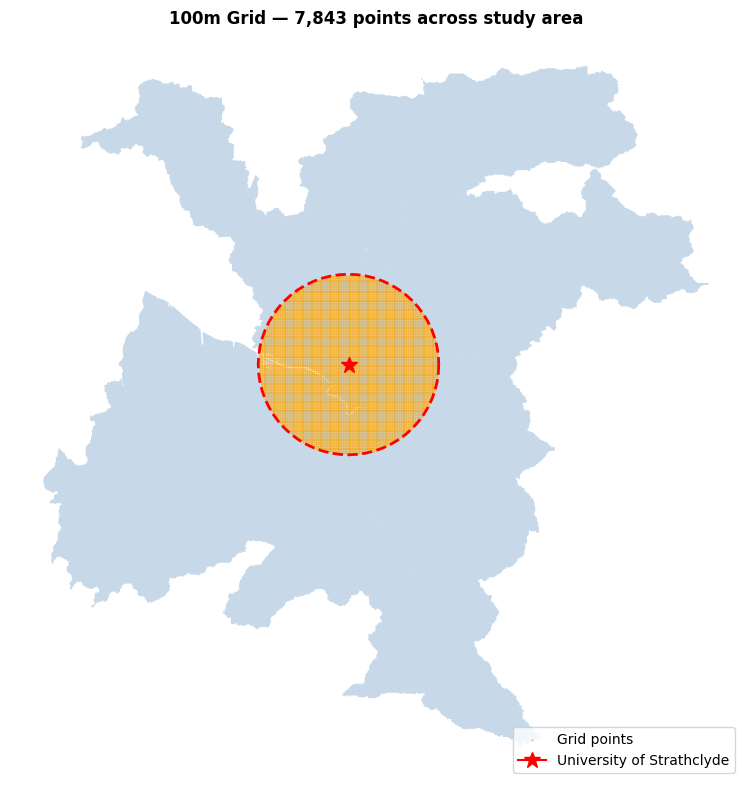

Grid created: 7,843 points ready for feature engineering


In [23]:

fig, ax = plt.subplots(figsize=(8, 8))

# Plot flood zones as background
pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.3, label='Flood zones')

# Plot grid points
grid.plot(ax=ax, color='orange', markersize=0.5, alpha=0.5, label='Grid points')

# Plot study boundary
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')

# University marker
ax.plot(UNI_X, UNI_Y, marker='*', color='red', markersize=12,
        label='University of Strathclyde')

ax.set_title("100m Grid — 7,843 points across study area",
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_grid.png", dpi=150)
plt.show()

print(f"Grid created: {len(grid):,} points ready for feature engineering")

In [24]:
# ── STEP 2: Attach Elevation to Each Grid Point ────────────
# For each of the 7,843 grid points we find the nearest
# NASA SRTM elevation point and attach its elevation value
# This is called a "spatial join" — matching points by location

from shapely.ops import nearest_points

print("Attaching elevation to grid points...")
print("This may take 1-2 minutes for 7,843 points...")

# Load elevation data
elevation = gpd.read_file(NASA_ELEV)

# Method: spatial join using nearest neighbour
# For each grid point find the closest elevation point
grid_with_elev = gpd.sjoin_nearest(
    grid,
    elevation[['elevation', 'geometry']],
    how='left',
    distance_col='elev_dist'
)

# Clean up — remove duplicate columns from the join
grid_with_elev = grid_with_elev.drop(columns=['index_right', 'elev_dist'])

# Check results
print(f"\nGrid points: {len(grid_with_elev):,}")
print(f"Null elevations: {grid_with_elev['elevation'].isnull().sum()}")
print(f"\nElevation statistics:")
print(grid_with_elev['elevation'].describe().round(1))
print(f"\nFirst 5 rows:")
print(grid_with_elev[['grid_id', 'elevation', 'geometry']].head())

Attaching elevation to grid points...
This may take 1-2 minutes for 7,843 points...

Grid points: 7,843
Null elevations: 0

Elevation statistics:
count    7843.0
mean       42.1
std        27.5
min       -15.0
25%        20.0
50%        33.0
75%        63.0
max       127.0
Name: elevation, dtype: float64

First 5 rows:
   grid_id  elevation               geometry
0        0          8  POINT (255983 665006)
1        1         17  POINT (256083 664106)
2        2         14  POINT (256083 664206)
3        3         13  POINT (256083 664306)
4        4         12  POINT (256083 664406)


In [25]:
# ── STEP 3: Distance to Nearest Water Body ─────────────────
# For each grid point calculate the distance in metres
# to the nearest water body (River Clyde, River Kelvin etc)
# This is the single strongest flood risk predictor

from shapely.ops import unary_union

print("Calculating distance to nearest water body...")
print("Merging all water polygons into one shape first...")

# Load water data
water = gpd.read_file(OSM_WATER)

# Merge all 195 water polygons into one single shape
# This avoids counting the same river multiple times
water_union = water.geometry.union_all()
print(f"Water bodies merged into single geometry")

# Calculate distance from each grid point to nearest water edge
print(f"Calculating distances for {len(grid_with_elev):,} points...")
print("This takes about 1-2 minutes...")

grid_with_elev['dist_to_water'] = grid_with_elev.geometry.distance(water_union)

# Check results
print(f"\nNull distances: {grid_with_elev['dist_to_water'].isnull().sum()}")
print(f"\nDistance to water statistics (metres):")
print(grid_with_elev['dist_to_water'].describe().round(1))

# How many points are within 500m of water
near_water = grid_with_elev[grid_with_elev['dist_to_water'] <= 500]
print(f"\nPoints within 500m of water: {len(near_water):,} "
      f"({len(near_water)/len(grid_with_elev)*100:.1f}%)")
print(f"Points within 100m of water: "
      f"{len(grid_with_elev[grid_with_elev['dist_to_water'] <= 100]):,}")

Calculating distance to nearest water body...
Merging all water polygons into one shape first...
Water bodies merged into single geometry
Calculating distances for 7,843 points...
This takes about 1-2 minutes...

Null distances: 0

Distance to water statistics (metres):
count    7843.0
mean      506.7
std       368.4
min         0.0
25%       221.6
50%       447.2
75%       724.4
max      2258.8
Name: dist_to_water, dtype: float64

Points within 500m of water: 4,356 (55.5%)
Points within 100m of water: 922


In [26]:
# ── STEP 4: Building Count within 250m ─────────────────────
# For each grid point count how many buildings fall
# within a 250m radius
# High building count = dense urban area = less natural drainage
# = higher flood risk when combined with low elevation

from shapely.geometry import Point

print("Calculating building count within 250m of each grid point...")
print("This may take 2-3 minutes...")

# Load buildings
buildings = gpd.read_file(OSM_BUILD)

# Create spatial index for faster searching
buildings_sindex = buildings.sindex

# For each grid point count buildings within 250m
building_counts = []

for idx, row in grid_with_elev.iterrows():
    # Create 250m buffer around this grid point
    buffer = row.geometry.buffer(250)

    # Use spatial index to find candidate buildings quickly
    possible_matches_idx = list(buildings_sindex.intersection(buffer.bounds))
    possible_matches = buildings.iloc[possible_matches_idx]

    # Count buildings actually within the buffer
    precise_matches = possible_matches[possible_matches.geometry.within(buffer)]
    building_counts.append(len(precise_matches))

grid_with_elev['building_count'] = building_counts

# Check results
print(f"\nNull building counts: {grid_with_elev['building_count'].isnull().sum()}")
print(f"\nBuilding count statistics:")
print(grid_with_elev['building_count'].describe().round(1))

# Distribution check
print(f"\nPoints with 0 buildings:    {len(grid_with_elev[grid_with_elev['building_count']==0]):,}")
print(f"Points with 1-10 buildings: {len(grid_with_elev[grid_with_elev['building_count'].between(1,10)]):,}")
print(f"Points with 11-50:          {len(grid_with_elev[grid_with_elev['building_count'].between(11,50)]):,}")
print(f"Points with 50+:            {len(grid_with_elev[grid_with_elev['building_count']>50]):,}")

Calculating building count within 250m of each grid point...
This may take 2-3 minutes...

Null building counts: 0

Building count statistics:
count    7843.0
mean       92.0
std        77.8
min         0.0
25%        28.0
50%        75.0
75%       140.0
max       419.0
Name: building_count, dtype: float64

Points with 0 buildings:    586
Points with 1-10 buildings: 478
Points with 11-50:          1,933
Points with 50+:            4,846


In [27]:
# ── STEP 5: Road Count within 250m ─────────────────────────
# For each grid point count how many road nodes fall
# within a 250m radius
# High road count = highly urbanised, impermeable surfaces
# = water cannot drain = higher flood risk

print("Calculating road count within 250m of each grid point...")
print("This may take 2-3 minutes...")

# Load roads
roads = gpd.read_file(OSM_ROADS)

# Create spatial index for faster searching
roads_sindex = roads.sindex

# For each grid point count road nodes within 250m
road_counts = []

for idx, row in grid_with_elev.iterrows():
    # Create 250m buffer around this grid point
    buffer = row.geometry.buffer(250)

    # Use spatial index to find candidate roads quickly
    possible_matches_idx = list(roads_sindex.intersection(buffer.bounds))
    possible_matches = roads.iloc[possible_matches_idx]

    # Count road nodes actually within the buffer
    precise_matches = possible_matches[possible_matches.geometry.within(buffer)]
    road_counts.append(len(precise_matches))

grid_with_elev['road_count'] = road_counts

# Check results
print(f"\nNull road counts: {grid_with_elev['road_count'].isnull().sum()}")
print(f"\nRoad count statistics:")
print(grid_with_elev['road_count'].describe().round(1))

# Distribution check
print(f"\nPoints with 0 road nodes:   {len(grid_with_elev[grid_with_elev['road_count']==0]):,}")
print(f"Points with 1-20:           {len(grid_with_elev[grid_with_elev['road_count'].between(1,20)]):,}")
print(f"Points with 21-100:         {len(grid_with_elev[grid_with_elev['road_count'].between(21,100)]):,}")
print(f"Points with 100+:           {len(grid_with_elev[grid_with_elev['road_count']>100]):,}")

Calculating road count within 250m of each grid point...
This may take 2-3 minutes...

Null road counts: 0

Road count statistics:
count    7843.0
mean       60.2
std        61.7
min         0.0
25%        22.0
50%        42.0
75%        79.0
max       680.0
Name: road_count, dtype: float64

Points with 0 road nodes:   516
Points with 1-20:           1,281
Points with 21-100:         4,688
Points with 100+:           1,358


In [28]:
# ── STEP 6: Create Flood Risk Label ────────────────────────
# For each grid point:
# 1. Check if it falls inside a SEPA PVA flood zone
# 2. Combine with elevation to create 3 risk classes:
#    High risk (2):   Inside PVA AND elevation <= 10m
#    Medium risk (1): Inside PVA AND elevation 10-30m
#    Low risk (0):    Outside PVA OR elevation > 30m

print("Creating flood risk labels...")

# Step 6a: Check which grid points are inside a PVA zone
print("Checking which points fall inside SEPA flood zones...")

# Spatial join — attach PVA zone name to each grid point
grid_labelled = gpd.sjoin(
    grid_with_elev,
    pva_glasgow[['PVA_Name', 'geometry']],
    how='left',
    predicate='within'
)

# If a point matched a PVA zone it will have a PVA_Name
# If not it will be NaN
grid_labelled['inside_pva'] = grid_labelled['PVA_Name'].notna().astype(int)

print(f"Points inside a PVA zone:   {grid_labelled['inside_pva'].sum():,} "
      f"({grid_labelled['inside_pva'].sum()/len(grid_labelled)*100:.1f}%)")
print(f"Points outside all PVA zones: {(grid_labelled['inside_pva']==0).sum():,} "
      f"({(grid_labelled['inside_pva']==0).sum()/len(grid_labelled)*100:.1f}%)")

# Step 6b: Combine with elevation to create 3 risk classes
def assign_risk(row):
    if row['inside_pva'] == 1 and row['elevation'] <= 10:
        return 2  # High risk
    elif row['inside_pva'] == 1 and row['elevation'] <= 30:
        return 1  # Medium risk
    else:
        return 0  # Low risk

grid_labelled['flood_risk'] = grid_labelled.apply(assign_risk, axis=1)

# Check class distribution
print(f"\nFlood risk class distribution:")
counts = grid_labelled['flood_risk'].value_counts().sort_index()
for label, count in counts.items():
    name = {0: 'Low risk', 1: 'Medium risk', 2: 'High risk'}[label]
    pct = count/len(grid_labelled)*100
    bar = '█' * int(pct/2)
    print(f"  Class {label} ({name}): {count:,} ({pct:.1f}%) {bar}")

Creating flood risk labels...
Checking which points fall inside SEPA flood zones...
Points inside a PVA zone:   7,749 (98.8%)
Points outside all PVA zones: 94 (1.2%)

Flood risk class distribution:
  Class 0 (Low risk): 4,348 (55.4%) ███████████████████████████
  Class 1 (Medium risk): 2,874 (36.6%) ██████████████████
  Class 2 (High risk): 621 (7.9%) ███


In [29]:
def assign_risk(row):
    if row['inside_pva'] == 1 and row['elevation'] <= 15:
        return 2  # High risk
    elif row['inside_pva'] == 1 and row['elevation'] <= 35:
        return 1  # Medium risk
    else:
        return 0  # Low risk

grid_labelled['flood_risk'] = grid_labelled.apply(assign_risk, axis=1)

print("Updated flood risk class distribution:")
counts = grid_labelled['flood_risk'].value_counts().sort_index()
for label, count in counts.items():
    name = {0: 'Low risk', 1: 'Medium risk', 2: 'High risk'}[label]
    pct = count/len(grid_labelled)*100
    bar = '█' * int(pct/2)
    print(f"  Class {label} ({name}): {count:,} ({pct:.1f}%) {bar}")

Updated flood risk class distribution:
  Class 0 (Low risk): 3,790 (48.3%) ████████████████████████
  Class 1 (Medium risk): 2,698 (34.4%) █████████████████
  Class 2 (High risk): 1,355 (17.3%) ████████


Feature means by flood risk class:
                 elevation  dist_to_water  building_count  road_count
Low risk (0)          65.2          588.9            88.8        47.1
Medium risk (1)       25.5          503.0           113.4        70.4
High risk (2)         10.7          284.1            58.6        76.4

Expected pattern:
  Elevation:     High risk LOWEST  → Low risk HIGHEST
  Dist to water: High risk CLOSEST → Low risk FURTHEST
  Building count: varies by area
  Road count:     varies by area

Plotting risk class map...


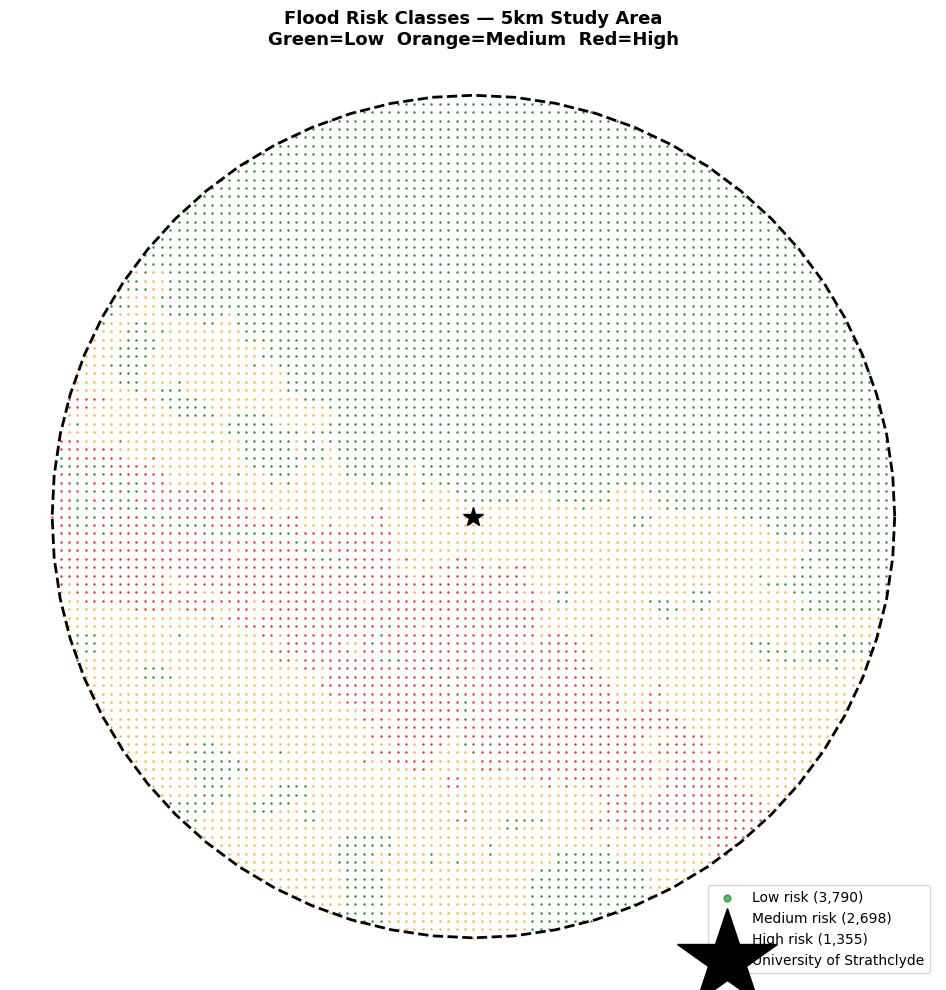


Final class counts:
  Total grid points: 7,843
  Low risk (0):      3,790
  Medium risk (1):   2,698
  High risk (2):     1,355

Thresholds used:
  High risk:   inside PVA AND elevation <= 15m
  Medium risk: inside PVA AND elevation 10-35m
  Low risk:    outside PVA OR elevation > 35m


In [30]:
# ── SANITY CHECK 1: Feature means per class ────────────────
# Do the features make logical sense for each risk class?
# High risk should have: lower elevation, closer to water

print("Feature means by flood risk class:")
print("=" * 55)

summary = grid_labelled.groupby('flood_risk')[
    ['elevation', 'dist_to_water', 'building_count', 'road_count']
].mean().round(1)

summary.index = ['Low risk (0)', 'Medium risk (1)', 'High risk (2)']
print(summary.to_string())

print("\n" + "=" * 55)
print("Expected pattern:")
print("  Elevation:     High risk LOWEST  → Low risk HIGHEST")
print("  Dist to water: High risk CLOSEST → Low risk FURTHEST")
print("  Building count: varies by area")
print("  Road count:     varies by area")

# ── SANITY CHECK 2: Visual map of risk classes ─────────────
print("\nPlotting risk class map...")

fig, ax = plt.subplots(figsize=(10, 10))

# Plot each risk class in different colour
colors = {0: 'green', 1: 'orange', 2: 'red'}
labels = {0: 'Low risk', 1: 'Medium risk', 2: 'High risk'}

for risk_class in [0, 1, 2]:
    subset = grid_labelled[grid_labelled['flood_risk'] == risk_class]
    subset.plot(ax=ax, color=colors[risk_class],
                markersize=1, alpha=0.6,
                label=f"{labels[risk_class]} ({len(subset):,})")

# Study boundary
uni_buffer.plot(ax=ax, color='none', edgecolor='black',
                linewidth=2, linestyle='--')

# University marker
ax.plot(UNI_X, UNI_Y, marker='*', color='black',
        markersize=15, label='University of Strathclyde')

ax.set_title("Flood Risk Classes — 5km Study Area\n"
             "Green=Low  Orange=Medium  Red=High",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right', markerscale=5)
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/flood_risk_labels.png", dpi=150)
plt.show()

# ── SANITY CHECK 3: Class counts confirmation ───────────────
print(f"\nFinal class counts:")
print(f"  Total grid points: {len(grid_labelled):,}")
print(f"  Low risk (0):      {(grid_labelled['flood_risk']==0).sum():,}")
print(f"  Medium risk (1):   {(grid_labelled['flood_risk']==1).sum():,}")
print(f"  High risk (2):     {(grid_labelled['flood_risk']==2).sum():,}")
print(f"\nThresholds used:")
print(f"  High risk:   inside PVA AND elevation <= 15m")
print(f"  Medium risk: inside PVA AND elevation 10-35m")
print(f"  Low risk:    outside PVA OR elevation > 35m")

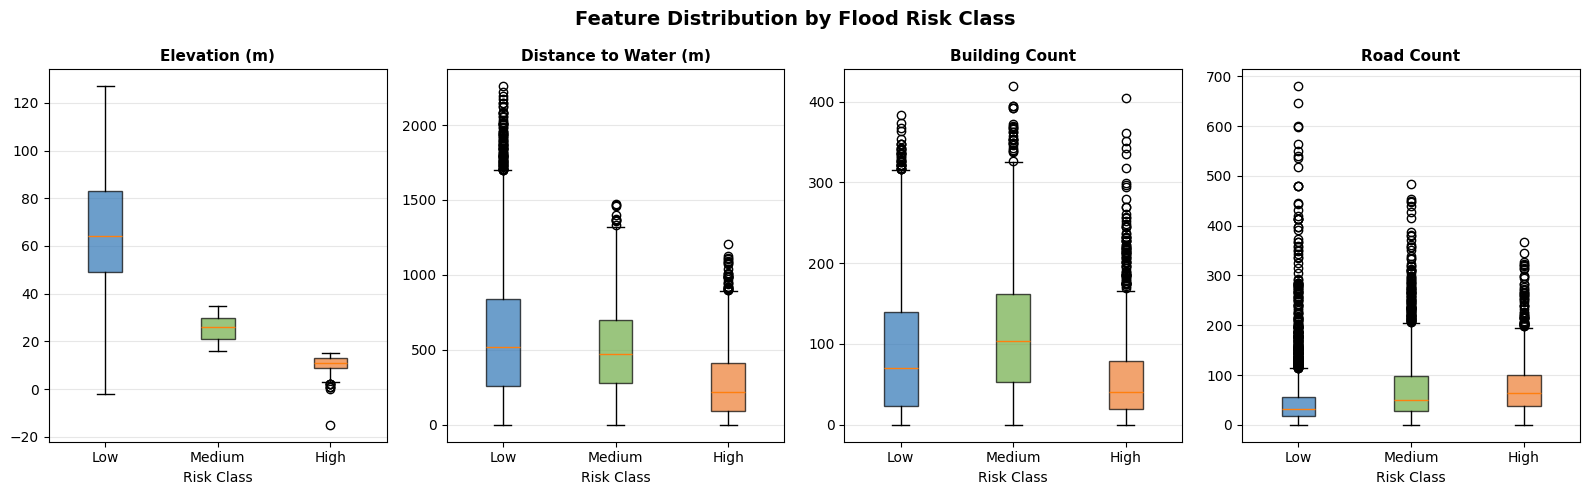

Visual 1 saved!


In [31]:
# Visual 1: How each feature varies across risk classes
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

features = ['elevation', 'dist_to_water', 'building_count', 'road_count']
titles = ['Elevation (m)', 'Distance to Water (m)', 'Building Count', 'Road Count']
colors = ['#2E75B6', '#70AD47', '#ED7D31']
labels = ['Low', 'Medium', 'High']

df_plot = grid_labelled[features + ['flood_risk']].drop_duplicates()

for ax, feat, title in zip(axes, features, titles):
    data = [df_plot[df_plot['flood_risk']==c][feat].values for c in [0,1,2]]
    bp = ax.boxplot(data, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Risk Class')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Feature Distribution by Flood Risk Class", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/visual1_feature_distributions.png", dpi=150)
plt.show()
print("Visual 1 saved!")

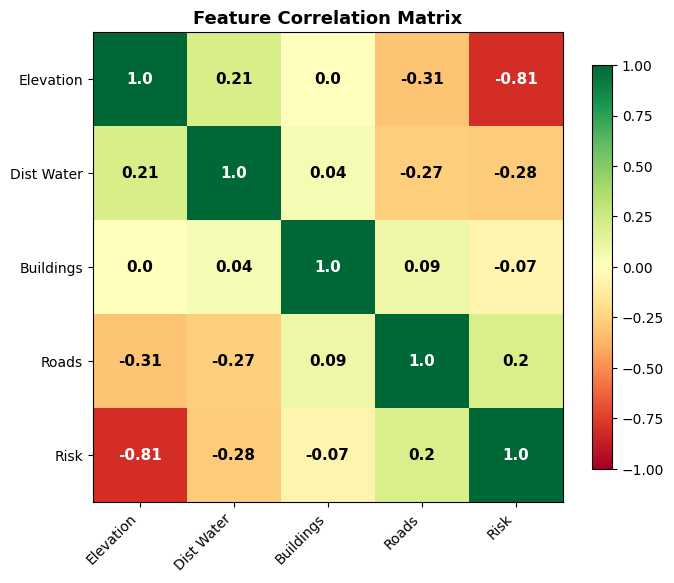

Visual 2 saved!


In [32]:
# Visual 2: Correlation heatmap
import numpy as np

feature_cols = ['elevation', 'dist_to_water', 'building_count', 'road_count', 'flood_risk']
df_corr = grid_labelled[feature_cols].drop_duplicates()
corr = df_corr.corr().round(2)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(['Elevation', 'Dist Water', 'Buildings', 'Roads', 'Risk'],
                   rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(['Elevation', 'Dist Water', 'Buildings', 'Roads', 'Risk'],
                   fontsize=10)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]}", ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')

ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/visual2_correlation_heatmap.png", dpi=150)
plt.show()
print("Visual 2 saved!")

/var/folders/1t/s4nhjjr55y7cv2zhjd_7k0q40000gn/T/ipykernel_1750/3000012657.py:16: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(loc='lower right', markerscale=5, fontsize=8)


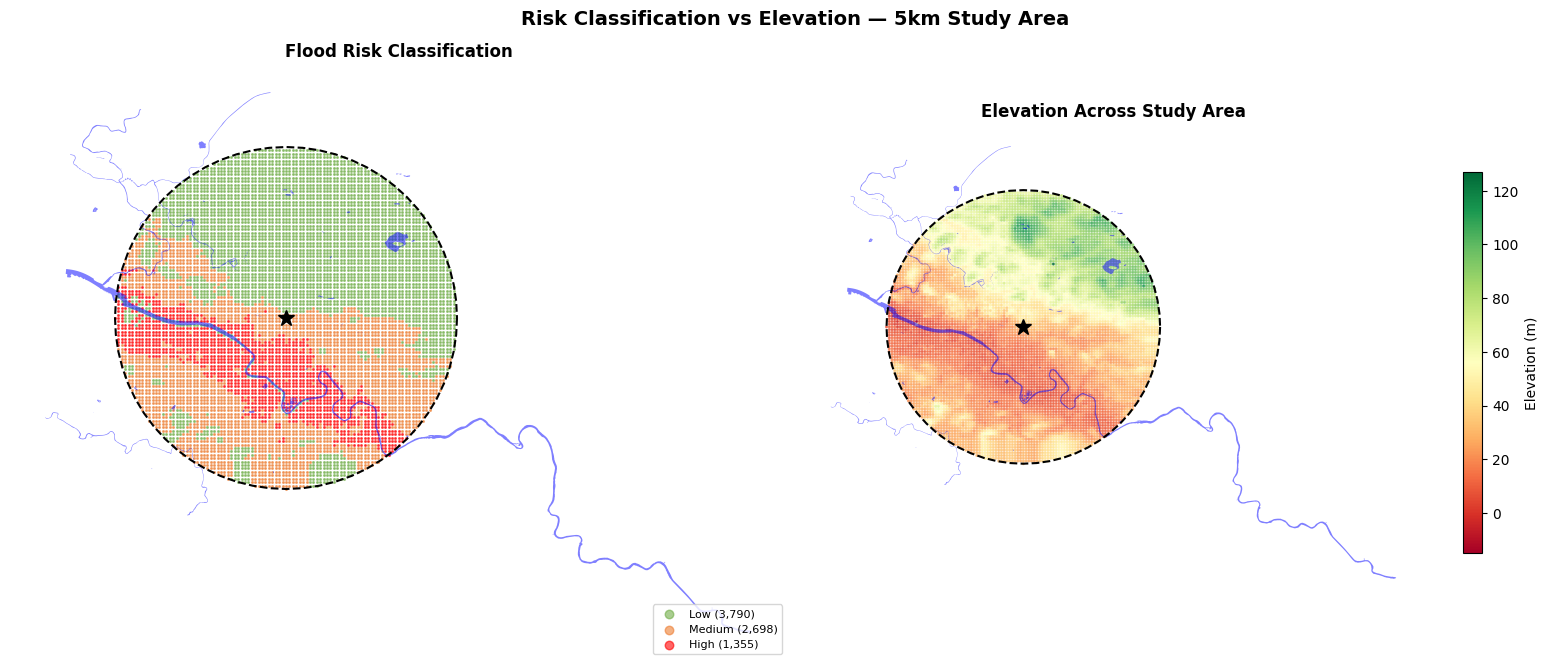

Visual 3 saved!


In [33]:
# Visual 3: Risk map with water bodies overlaid
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_plot = grid_labelled.drop_duplicates(subset='grid_id')
colors_map = {0: '#70AD47', 1: '#ED7D31', 2: '#FF0000'}

# Left: Risk class map
for risk, color in colors_map.items():
    subset = df_plot[df_plot['flood_risk'] == risk]
    subset.plot(ax=axes[0], color=color, markersize=1.5,
                alpha=0.6, label=f"{'Low/Medium/High'.split('/')[risk]} ({len(subset):,})")
water.plot(ax=axes[0], color='blue', alpha=0.5, label='Water bodies')
uni_buffer.plot(ax=axes[0], color='none', edgecolor='black', linewidth=1.5, linestyle='--')
axes[0].plot(UNI_X, UNI_Y, marker='*', color='black', markersize=12)
axes[0].set_title("Flood Risk Classification", fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', markerscale=5, fontsize=8)
axes[0].axis('off')

# Right: Elevation heatmap
df_plot.plot(column='elevation', ax=axes[1], cmap='RdYlGn',
             markersize=1.5, alpha=0.7, legend=True,
             legend_kwds={'label': 'Elevation (m)', 'shrink': 0.6})
water.plot(ax=axes[1], color='blue', alpha=0.5)
uni_buffer.plot(ax=axes[1], color='none', edgecolor='black', linewidth=1.5, linestyle='--')
axes[1].plot(UNI_X, UNI_Y, marker='*', color='black', markersize=12)
axes[1].set_title("Elevation Across Study Area", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Risk Classification vs Elevation — 5km Study Area",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/visual3_risk_vs_elevation.png", dpi=150)
plt.show()
print("Visual 3 saved!")

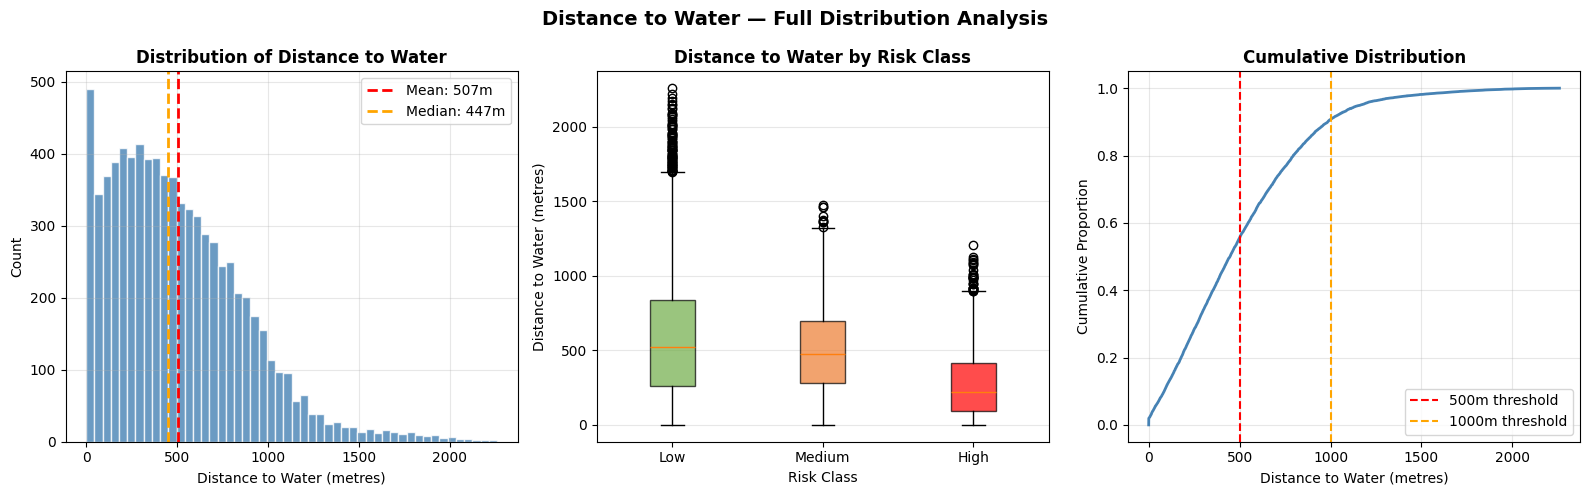

Distance to Water — Key Statistics:
  Min:    0.0m
  Max:    2258.8m
  Mean:   506.7m
  Median: 447.2m
  Std:    368.4m

Points within 100m:  922
Points within 500m:  4,356
Points within 1000m: 7,111
Points beyond 1000m: 732


In [34]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = grid_labelled.drop_duplicates(subset='grid_id')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Histogram of distance to water
axes[0].hist(df_plot['dist_to_water'], bins=50, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df_plot['dist_to_water'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f"Mean: {df_plot['dist_to_water'].mean():.0f}m")
axes[0].axvline(df_plot['dist_to_water'].median(), color='orange', 
                linestyle='--', linewidth=2, label=f"Median: {df_plot['dist_to_water'].median():.0f}m")
axes[0].set_xlabel("Distance to Water (metres)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Distance to Water", fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Middle: Distance by risk class (boxplot)
colors = ['#70AD47', '#ED7D31', '#FF0000']
data = [df_plot[df_plot['flood_risk']==c]['dist_to_water'].values for c in [0,1,2]]
bp = axes[1].boxplot(data, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_xlabel("Risk Class")
axes[1].set_ylabel("Distance to Water (metres)")
axes[1].set_title("Distance to Water by Risk Class", fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Right: Cumulative distribution
sorted_dist = np.sort(df_plot['dist_to_water'])
cumulative = np.arange(1, len(sorted_dist)+1) / len(sorted_dist)
axes[2].plot(sorted_dist, cumulative, color='steelblue', linewidth=2)
axes[2].axvline(500, color='red', linestyle='--', linewidth=1.5, label='500m threshold')
axes[2].axvline(1000, color='orange', linestyle='--', linewidth=1.5, label='1000m threshold')
axes[2].set_xlabel("Distance to Water (metres)")
axes[2].set_ylabel("Cumulative Proportion")
axes[2].set_title("Cumulative Distribution", fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Distance to Water — Full Distribution Analysis", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/water_distance_distribution.png", dpi=150)
plt.show()

# Print key stats
print("Distance to Water — Key Statistics:")
print(f"  Min:    {df_plot['dist_to_water'].min():.1f}m")
print(f"  Max:    {df_plot['dist_to_water'].max():.1f}m")
print(f"  Mean:   {df_plot['dist_to_water'].mean():.1f}m")
print(f"  Median: {df_plot['dist_to_water'].median():.1f}m")
print(f"  Std:    {df_plot['dist_to_water'].std():.1f}m")
print(f"\nPoints within 100m:  {len(df_plot[df_plot['dist_to_water']<=100]):,}")
print(f"Points within 500m:  {len(df_plot[df_plot['dist_to_water']<=500]):,}")
print(f"Points within 1000m: {len(df_plot[df_plot['dist_to_water']<=1000]):,}")
print(f"Points beyond 1000m: {len(df_plot[df_plot['dist_to_water']>1000]):,}")

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load HadUK-Grid Scotland rainfall data ──────────────────
df = pd.read_csv(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/001_SEPA/Scotland1.txt",
    sep=r'\s+',
    skiprows=5,
    na_values=['---']
)

# Convert all to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min():.0f} to {df['year'].max():.0f}")
print(f"Columns: {df.columns.tolist()}")

✅ Data loaded successfully!
Shape: (191, 18)
Years: 1836 to 2026
Columns: ['year', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'win', 'spr', 'sum', 'aut', 'ann']


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Step 1: Load CSV ────────────────────────────────────────
df = pd.read_csv(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/001_SEPA/scotland_rainfall_hadukgrid.csv"
)

print("✅ Data loaded!")
print(f"\nShape: {df.shape}")
print(f"Year range: {int(df['year'].min())} to {int(df['year'].max())}")

✅ Data loaded!

Shape: (191, 18)
Year range: 1836 to 2026


In [60]:
# Step 2 — Head
print("First 5 rows:")
print(df.head())

First 5 rows:
   year    jan    feb    mar   apr    may    jun    jul    aug    sep    oct  \
0  1836  163.5   96.3  147.5  92.1   16.4   87.8  150.0   90.1  157.6  156.2   
1  1837   70.0  136.5   48.6  68.7   51.3   74.1  120.0  103.8   79.4  129.7   
2  1838   49.0   46.3  105.7  71.6   63.8  155.8  114.8  129.5   99.6  113.5   
3  1839  113.8   90.3  112.0  39.5   57.4   72.0   91.7   85.7  186.9  125.3   
4  1840  169.7   78.7   23.3  33.5  106.0   95.6  106.1   93.5  149.8  101.4   

     nov    dec    win    spr    sum    aut     ann  
0  169.8  175.4    NaN  256.1  327.9  483.6  1502.8  
1  137.2  114.7  381.9  168.6  298.0  346.3  1134.1  
2  118.9  105.3  210.0  241.2  400.2  332.1  1174.1  
3   97.8  129.8  309.5  208.9  249.4  410.0  1202.3  
4  110.6   71.2  378.3  162.9  295.3  361.8  1139.6  


In [61]:
# Step 3 — Tail
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
     year    jan    feb    mar    apr    may    jun    jul    aug    sep  \
186  2022  113.7  226.0   62.1   87.6  119.9   80.7   88.3   82.1  138.5   
187  2023  178.1  101.4  130.2   76.5   39.7   75.4  157.9  102.8  170.3   
188  2024  177.1  155.8  113.4  142.8   82.3   91.5   91.1  196.7   79.9   
189  2025   94.0  102.0   78.4   44.7   79.4  118.5  103.0  101.2  125.9   
190  2026  155.2  116.5  148.6  108.8   69.6  118.7    NaN    NaN    NaN   

       oct    nov    dec    win    spr    sum    aut     ann  
186  200.3  205.5  149.9  468.5  269.5  251.2  544.4  1554.7  
187  210.9  126.3  255.7  429.4  246.4  336.1  507.6  1625.2  
188  124.4   92.7  249.5  588.6  338.5  379.3  297.1  1597.3  
189  181.9  183.7  177.9  445.5  202.5  322.7  491.6  1390.7  
190    NaN    NaN    NaN    NaN    NaN    NaN    NaN     NaN  


In [62]:
# Step 4 — Info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    191 non-null    int64  
 1   jan     191 non-null    float64
 2   feb     191 non-null    float64
 3   mar     191 non-null    float64
 4   apr     191 non-null    float64
 5   may     191 non-null    float64
 6   jun     191 non-null    float64
 7   jul     190 non-null    float64
 8   aug     190 non-null    float64
 9   sep     190 non-null    float64
 10  oct     190 non-null    float64
 11  nov     190 non-null    float64
 12  dec     190 non-null    float64
 13  win     189 non-null    float64
 14  spr     190 non-null    float64
 15  sum     190 non-null    float64
 16  aut     190 non-null    float64
 17  ann     190 non-null    float64
dtypes: float64(17), int64(1)
memory usage: 27.0 KB


In [63]:
# Step 5 — Describe monthly columns
months = ['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec']
print("Monthly rainfall statistics (mm):")
print(df[months].describe().round(1))

Monthly rainfall statistics (mm):
         jan    feb    mar    apr    may    jun    jul    aug    sep    oct  \
count  191.0  191.0  191.0  191.0  191.0  191.0  190.0  190.0  190.0  190.0   
mean   148.7  114.3  106.2   82.7   79.8   85.3  102.8  117.7  119.8  150.3   
std     52.8   51.8   42.5   30.8   30.7   29.4   31.1   40.6   43.4   49.0   
min     33.6   12.9    8.8    6.5    9.6   28.4   24.4    4.2   15.8   19.2   
25%    109.6   76.5   76.0   63.0   57.4   65.5   82.5   92.1   86.0  113.8   
50%    142.6  109.7  102.0   78.4   78.5   80.1  103.1  112.6  120.4  150.0   
75%    185.4  142.2  133.8  103.8  101.6  105.0  121.7  142.8  152.0  184.4   
max    302.8  289.5  248.4  194.0  188.6  176.5  191.2  228.7  265.1  254.2   

         nov    dec  
count  190.0  190.0  
mean   144.1  155.4  
std     47.1   54.5  
min     30.5   39.2  
25%    108.2  117.3  
50%    144.4  148.6  
75%    176.8  191.4  
max    260.4  322.6  


In [64]:
# Step 6 — Null values
print("Null values per column:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

Null values per column:
year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     1
aug     1
sep     1
oct     1
nov     1
dec     1
win     2
spr     1
sum     1
aut     1
ann     1
dtype: int64

Total nulls: 12


In [65]:
# Step 6 — Null values
print("Null values per column:")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

Null values per column:
year    0
jan     0
feb     0
mar     0
apr     0
may     0
jun     0
jul     1
aug     1
sep     1
oct     1
nov     1
dec     1
win     2
spr     1
sum     1
aut     1
ann     1
dtype: int64

Total nulls: 12


In [66]:
# Step 7 — Filter to 2010-2026
df_recent = df[df['year'] >= 2010].copy()
df_recent = df_recent.reset_index(drop=True)

print(f"Recent years: {len(df_recent)}")
print(f"\nYears available:")
print(df_recent['year'].values)

print(f"\nRecent data:")
print(df_recent[['year','jan','apr','jul','oct','ann']])

Recent years: 17

Years available:
[2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024 2025 2026]

Recent data:
    year    jan    apr    jul    oct     ann
0   2010   92.8   85.4  164.9  147.5  1245.6
1   2011  135.6   77.3   98.7  204.1  1862.9
2   2012  181.7  114.0  125.3  150.9  1596.2
3   2013  147.2  115.6   81.5  190.1  1458.1
4   2014  214.1   92.8   86.2  246.1  1738.3
5   2015  250.8   78.3  151.0   92.0  1837.4
6   2016  251.5   99.0  137.6   65.6  1486.3
7   2017   99.9   62.9  109.8  177.9  1522.8
8   2018  184.0   85.0   79.3  168.5  1395.2
9   2019  106.8   52.8  128.6  148.0  1558.1
10  2020  202.4   30.3  134.0  241.3  1801.6
11  2021  142.6   37.0   68.9  226.3  1391.2
12  2022  113.7   87.6   88.3  200.3  1554.7
13  2023  178.1   76.5  157.9  210.9  1625.2
14  2024  177.1  142.8   91.1  124.4  1597.3
15  2025   94.0   44.7  103.0  181.9  1390.7
16  2026  155.2  108.8    NaN    NaN     NaN


In [67]:
# Step 8 — Monthly averages 2010-2025 (exclude 2026 partial)
df_2010_2025 = df_recent[df_recent['year'] <= 2025].copy()

months = ['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec']
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print("Monthly averages 2010-2025 (mm):")
print(f"{'Month':<6} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 42)
for m, name in zip(months, month_names):
    mean = df_2010_2025[m].mean()
    std  = df_2010_2025[m].std()
    mn   = df_2010_2025[m].min()
    mx   = df_2010_2025[m].max()
    print(f"{name:<6} {mean:>8.1f} {std:>8.1f} {mn:>8.1f} {mx:>8.1f}")

print(f"\nAnnual average: {df_2010_2025['ann'].mean():.1f}mm")
print(f"Wettest year: {int(df_2010_2025.loc[df_2010_2025['ann'].idxmax(),'year'])} "
      f"({df_2010_2025['ann'].max():.1f}mm)")
print(f"Driest year:  {int(df_2010_2025.loc[df_2010_2025['ann'].idxmin(),'year'])} "
      f"({df_2010_2025['ann'].min():.1f}mm)")

Monthly averages 2010-2025 (mm):
Month      Mean      Std      Min      Max
------------------------------------------
Jan       160.8     52.6     92.8    251.5
Feb       143.0     56.8     81.7    277.3
Mar       110.1     37.5     51.6    178.6
Apr        80.1     30.1     30.3    142.8
May        92.3     39.7     39.7    188.6
Jun        89.3     31.1     39.5    152.8
Jul       112.9     30.3     68.9    164.9
Aug       128.1     40.6     82.1    207.9
Sep       125.7     41.6     39.3    187.6
Oct       173.5     50.7     65.6    246.1
Nov       154.3     37.9     92.7    239.8
Dec       196.4     69.1     62.0    322.6

Annual average: 1566.4mm
Wettest year: 2011 (1862.9mm)
Driest year:  2010 (1245.6mm)


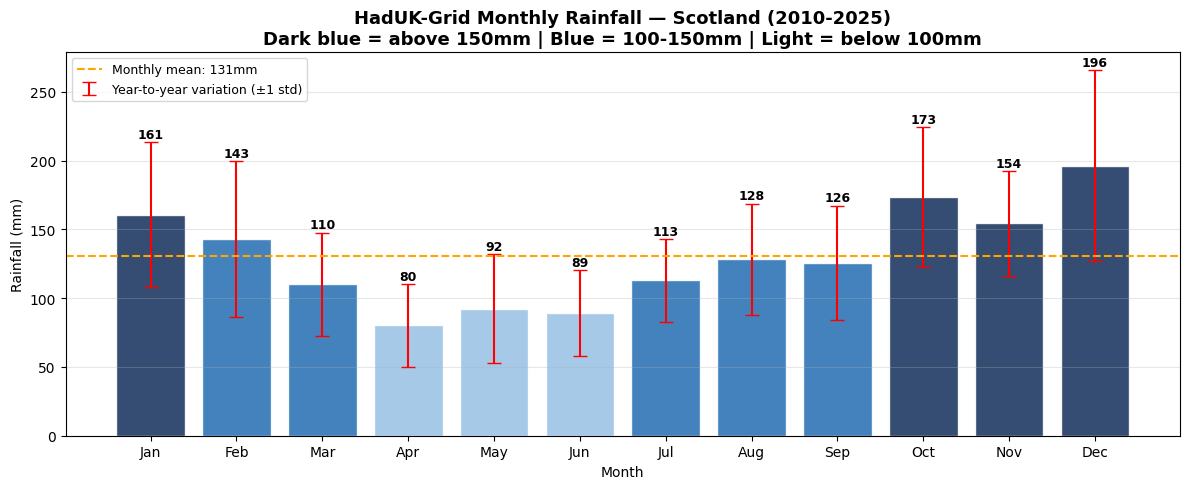

Chart saved!


In [68]:
# Step 9 — Monthly rainfall bar chart
months = ['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec']
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = [df_2010_2025[m].mean() for m in months]
monthly_std = [df_2010_2025[m].std() for m in months]

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#1F3864' if v >= 150 else '#2E75B6' if v >= 100 else '#9DC3E6'
          for v in monthly_avg]

bars = ax.bar(month_names, monthly_avg, color=colors,
              edgecolor='white', alpha=0.9)

ax.errorbar(month_names, monthly_avg, yerr=monthly_std,
            fmt='none', color='red', capsize=5,
            linewidth=1.5, label='Year-to-year variation (±1 std)')

for i, v in enumerate(monthly_avg):
    ax.text(i, v + monthly_std[i] + 3,
            f"{v:.0f}", ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=sum(monthly_avg)/12, color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Monthly mean: {sum(monthly_avg)/12:.0f}mm")

ax.set_title("HadUK-Grid Monthly Rainfall — Scotland (2010-2025)\n"
             "Dark blue = above 150mm | Blue = 100-150mm | Light = below 100mm",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm)")
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

MAPS_PATH = "/Users/riteshghorpade/Documents/010_Project/002_Dataset/004_Maps"
plt.savefig(f"{MAPS_PATH}/haduk_monthly_rainfall.png", dpi=150)
plt.show()
print("Chart saved!")